# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Load Dataset

In [45]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df['species'] = iris.target
df['species'] = df['species'].map({
    0:'Setosa',
    1:'Versicolor',
    2:'Virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


# 3. Exploratory Data Analysis (EDA)

In [46]:
# Dataset Shape
print("Shape",df.shape)

Shape (150, 5)


In [47]:
# Dataset Type
print(df.dtypes)

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


In [48]:
# Null Values
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [49]:
# Descriptive Sttistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# 4. Visualization

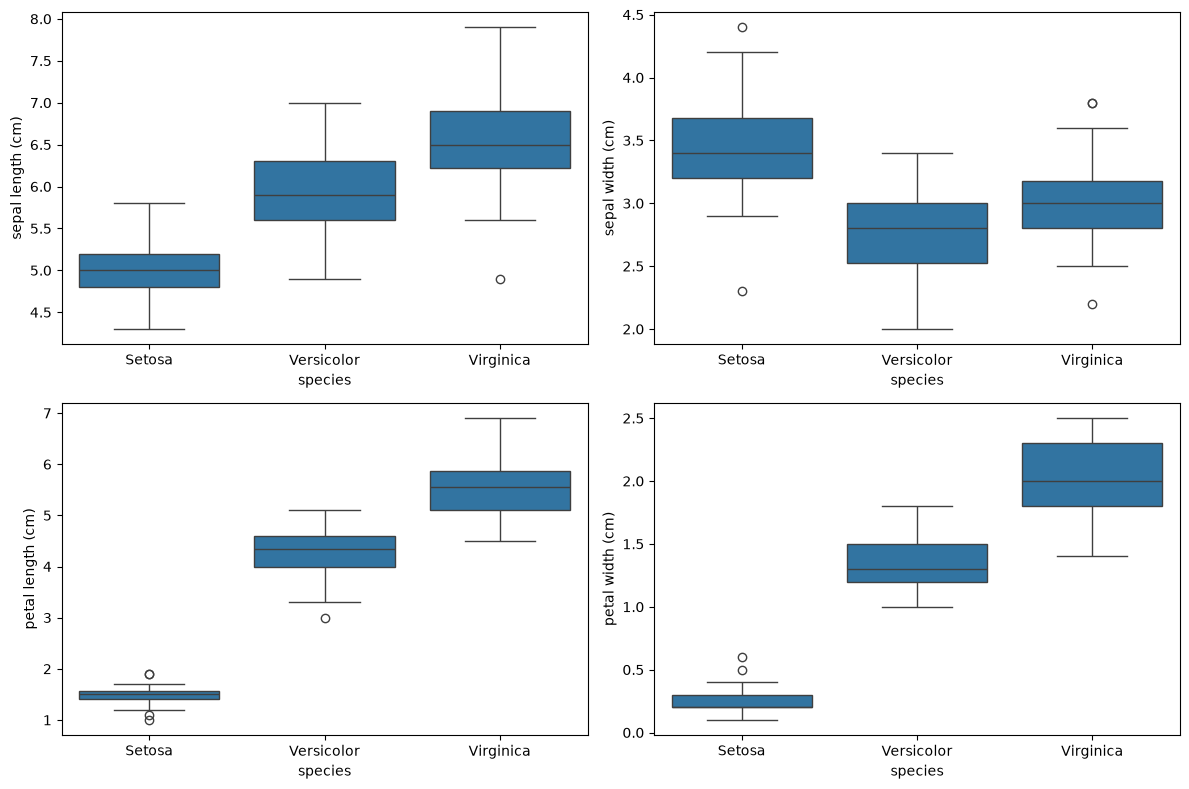

In [50]:
plt.figure(figsize=(12,8))

for i, col in enumerate(df.columns[:-1], 1):
    plt.subplot(2,2,i)
    sns.boxplot(x='species', y=col, data=df)

plt.tight_layout()
plt.show()

# 5. Feature Selection Discussion*

Petal Length and Petal Width are the most discriminative features because
they show clear separation among the three species in both pairplots and boxplots.

Sepal Length and Sepal Width contribute useful information but exhibit
greater overlap between species.

# 6. Prepare Data

In [51]:
X = iris.data
y = iris.target

In [52]:
# Train, Test and Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Model 1 Logistic Regression 

In [54]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [55]:
#Evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 8. K-Nearest Neighbours

In [56]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [57]:
#Evaluation
print("Accuracy:",
      accuracy_score(y_test, y_pred_knn))

print(confusion_matrix(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 9. Decision Tree Classifier


In [58]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# 10. Compare Models

In [59]:
lr_acc = accuracy_score(y_test, y_pred_lr)
knn_acc = accuracy_score(y_test, y_pred_knn)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Logistic Regression:", lr_acc)
print("KNN:", knn_acc)
print("Decision Tree:", dt_acc)

Logistic Regression: 1.0
KNN: 1.0
Decision Tree: 1.0


# 11. Best Model Conclusion

Three machine learning models were trained and evaluated:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree

All three models achieved an accuracy of 100% on the test dataset.

Logistic Regression is selected as the preferred model due to its simplicity,
fast training time, and high interpretability while maintaining perfect accuracy.
